# Multimodal AutoML LOOCV — SC × FC coupling  [지역 · Spearman · PCA 3 · pass]

SC(구조 연결, streamline 개수)와 FC(기능 연결)를 **같은 DK 84 ROI**(피질 68 + 피질하 16)로 맞춰 결합한다.
MSN–FC 쪽의 `multimodal_msn_fc68/automl_multimodal_MSN_FC68_coupling_PCA3_spearman.ipynb`와 같은 구성을 SC–FC로 옮긴 것이다.
뼈대(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize → scale → PCA)도 같다.

## 데이터 (루트와 `sc_dk84/`의 CSV를 `../`로 읽음)

| 파일 | 내용 |
|---|---|
| `sc_dk84/sc_strength_84_pass.csv` | SC strength 84개 (streamline 총수). 모델에 넣을 때 log(1 + count) |
| `fc_strength_68_16.csv` | FC strength 84개 |
| `sc_dk84/sc_full_84x84_pass.csv`, `fc_full_84x84_edited.csv` | edge 3486개씩 → coupling 계산에만 사용 |

## 표본
SC 45명 ∩ FC 44명 = **공통 44명** (sub-001은 FC 없음). 타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 뇌 피처 | nuisance (fold 안 train에서만 fit) |
|---|---|---|
| `Clinical_ONLY` | 없음 | — |
| `SC_PCA3` | SC strength 84 (log) → PCA 3 | age, sex, eTIV |
| `FC84_PCA3` | FC strength 84 → PCA 3 | age, sex, mean_fd |
| `Multimodal` | SC PCA3 + FC84 PCA3 (따로 줄여서 붙임, 6개) | 모달리티별로 따로 |
| `Coupling_S_PCA3` | ROI별 SC–FC coupling(Spearman) (pass 84개 / end는 계산 불가 영역 제외) → PCA 3 | age, sex, eTIV, mean_fd |

PCA 성분 수 3은 SC, FC, coupling 모두 같고, 기존 노트북과 맞춘 값이다.

## coupling 정의 (결과를 보기 전에 정한 규칙)

- 영역 i마다: SC 행렬의 i행(다른 83개 영역과의 streamline 수)과 FC 행렬의 i행의 **Spearman 순위 상관**. 사람당 영역 수만큼 값이 나온다.
- **partner가 3개 미만인 사람이 한 명이라도 있는 영역은 뺀다.** 3은 Spearman이 ±1 이외의 값을 낼 수 있는 최소 개수다.
  없는 값을 채워 넣지 않는다. pass에서는 해당 영역이 없고, end에서는 일부 영역이 빠진다(데이터 준비 셀이 출력한다).
- **SC가 0인 쌍은 뺀다** (Baum 2020, Qian 2026). streamline이 없는 쌍까지 넣으면 "연결이 있나 없나"가 순위를 지배한다.
- SC 값은 변환하지 않는다. Spearman은 순위만 쓰므로 log를 해도 결과가 같다.
- vas를 쓰지 않고 피험자 안에서만 계산하므로 CV 밖에서 미리 계산해도 leakage가 없다.

## 연결 기준: **pass** — streamline이 두 영역을 모두 지나가면 연결로 센다 (DSI Studio 기본값). **주 분석**

SC는 "무엇을 연결로 세느냐"에 따라 값이 크게 달라진다. 같은 사람들로 구한 영역별 coupling의 pass와 end 사이
상관이 0.525였다. 그래서 같은 분석을 두 기준으로 따로 만들었고(`..._pass.ipynb`, `..._end.ipynb`),
**주 분석은 pass, end는 민감도 분석**으로 결과를 보기 전에 정해 두었다. 어느 쪽이 좋게 나오든 둘 다 보고한다.

## 읽을 때 주의

- **coupling을 PCA로 줄이는 것은 coupling 문헌에 선례가 없는 우리 설계다.** MSN–FC 쪽과 같은 구성으로 맞추려고 만들었다.
- **이 노트북은 영역별 전부 · 전역 · ROI 결과를 본 뒤에 추가했다.** 미리 정한 분석이 아니므로 탐색적 결과로 읽는다.
- 잔차화 직전에 nuisance를 train 기준으로 표준화한다. 잔차는 수학적으로 같고, eTIV(백만 단위)로 인한 계산 정밀도
  문제를 막는다.
- `SC_PCA3`, `FC84_PCA3`, `Multimodal`(PCA 3)은 이 폴더의 다른 노트북과 같은 방식으로 계산한다 (같은 연결 기준끼리는 같은 값).
  `SC_PCA5`는 `sc_dk84/`의 SC PCA5 strength 노트북과 같은 계산이다.

### 같은 폴더의 변형

| 파일 | 내용 |
|---|---|
| `..._coupling_all_spearman_{pass,end}.ipynb` | 영역별 coupling 전부 (압축 없음) |
| `..._coupling_global_spearman_{pass,end}.ipynb` | 전역 coupling (사람당 1개) |
| `..._coupling_ROI_spearman_{pass,end}.ipynb` | Morph ROI 10개의 coupling |
| `..._coupling_PCA3_spearman_{pass,end}.ipynb` | 영역별 coupling → PCA 3 |
| `..._coupling_PCA5_spearman_{pass,end}.ipynb` | 영역별 coupling → PCA 5, SC·FC도 PCA 5 |
| `..._joint_PCA3_{pass,end}.ipynb` | SC 84 + FC 84를 먼저 붙이고 PCA 3 한 번 |


In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (SC 84 + FC 84, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'            # 데이터 CSV는 TMS 루트와 sc_dk84/ 에 있다
SC_RULE = 'pass'           # 'pass'(지나가면 셈, 주 분석) 또는 'end'(끝점 기준, 민감도 분석)

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

sc_s = load(f'sc_dk84/sc_strength_84_{SC_RULE}.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s = load('fc_strength_68_16.csv')                    # 앞 7열: ... mean_fd
sc_e = load(f'sc_dk84/sc_full_84x84_{SC_RULE}.csv')
fc_e = load('fc_full_84x84_edited.csv')

# --- ROI 매칭 확인: 접미사만 떼면 이름과 순서가 같아야 한다 ---
N_ROI = 84
ROIS = [c[:-len('_sc')] for c in sc_s.columns[7:]]
assert len(ROIS) == N_ROI, len(ROIS)
assert [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'strength ROI 순서 불일치'
sc_edge_cols, fc_edge_cols = list(sc_e.columns[7:]), list(fc_e.columns[7:])
assert [c[:-len('_sc')] for c in sc_edge_cols] == fc_edge_cols, 'edge 순서 불일치'

# --- 임상 변수는 두 파일 모두 structural CSV에서 왔으므로 공통 44명에서 같아야 한다 ---
chk = sc_s.merge(fc_s, on='rid', suffixes=('_s', '_f'))
for c in ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']:
    assert np.allclose(chk[f'{c}_s'], chk[f'{c}_f']), c

# --- rid inner join: 공통 44명 (SC에만 있는 sub-001이 빠진다) ---
df = (sc_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

# edge 표도 df와 같은 rid 순서로 맞춘다
E_sc = sc_e.set_index('rid').loc[df['rid'], sc_edge_cols].values.astype(float)   # (44, 3486) streamline 개수
E_fc = fc_e.set_index('rid').loc[df['rid'], fc_edge_cols].values                 # (44, 3486) Fisher z

IU = np.triu_indices(N_ROI, k=1)

# ---- ROI별 structure–function coupling ----
MIN_PARTNERS = 3          # Spearman이 +1/-1 이외의 값을 낼 수 있는 최소 개수

def to_matrix(edge_row):
    M = np.zeros((N_ROI, N_ROI))
    M[IU] = edge_row
    return M + M.T          # 대각은 0이라 아래에서 자동으로 빠진다

def coupling(sc_edges, fc_edges):
    """ROI i: SC i행과 FC i행의 Spearman rho. SC가 0이 아닌 partner만 쓴다 (Baum 2020, Qian 2026).

    partner가 MIN_PARTNERS 미만이거나 SC 값이 전부 같아 순위를 매길 수 없으면 NaN을 돌려준다.
    """
    S, F = to_matrix(sc_edges), to_matrix(fc_edges)
    out = np.full(N_ROI, np.nan)
    for i in range(N_ROI):
        k = S[i] > 0
        if k.sum() >= MIN_PARTNERS and np.ptp(S[i, k]) > 0:
            out[i] = spearmanr(S[i, k], F[i, k]).statistic
    return out

C_all = np.array([coupling(E_sc[k], E_fc[k]) for k in range(len(df))])            # (44, 84)
n_partner = np.array([(to_matrix(E_sc[k]) > 0).sum(1) for k in range(len(df))])    # (44, 84)

# 한 명이라도 계산할 수 없는 영역은 뺀다. 없는 값을 채워 넣지 않는다.
keep = ~np.isnan(C_all).any(axis=0)
ROIS_CP = [r for r, k in zip(ROIS, keep) if k]
X_coup = C_all[:, keep]
assert np.all(np.isfinite(X_coup))
dropped = [(r, int(np.isnan(C_all[:, j]).sum())) for j, r in enumerate(ROIS) if not keep[j]]

X_sc       = np.log1p(df[[f'{r}_sc' for r in ROIS]].values)   # SC를 피처로 쓸 때는 log(1 + count) (Tong 2026)
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_nuis_sc  = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_nuis_cp  = df[['age', 'sex', 'eTIV', 'mean_fd']].values     # coupling은 두 모달리티의 교란을 다 받는다
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
group      = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'연결 기준 {SC_RULE}  |  n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'SC strength {X_sc.shape[1]} | FC strength {X_fc.shape[1]} | coupling {X_coup.shape[1]} (영역별, PCA 3으로 줄임)')
print(f'0이 아닌 partner 수: 평균 {n_partner.mean():.1f}, 최소 {n_partner.min()}')
print(f'제외한 영역 {len(dropped)}개 (영역, 계산 불가 인원): {dropped}')
print(f'coupling 전체 평균 {X_coup.mean():+.3f} (SD {X_coup.std():.3f}) | '
      f'피험자별 전뇌 평균 {X_coup.mean(1).min():+.3f} ~ {X_coup.mean(1).max():+.3f}')


연결 기준 pass  |  n = 44  |  Active 25 / Sham 19
SC strength 84 | FC strength 84 | coupling 84 (영역별, PCA 3으로 줄임)
0이 아닌 partner 수: 평균 53.4, 최소 4
제외한 영역 0개 (영역, 계산 불가 인원): []
coupling 전체 평균 +0.254 (SD 0.187) | 피험자별 전뇌 평균 +0.177 ~ +0.365


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 3   # SC, FC, coupling 모두 같은 값 (기존 노트북과 동일)

DATA_TYPES = ['Clinical_ONLY', 'SC_PCA3', 'FC84_PCA3', 'Multimodal', 'Coupling_S_PCA3']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 모달리티별 nuisance residualization → scale → PCA → stack → StandardScaler
#    coupling도 같은 방식으로 PCA(N_PCA)로 줄인다
#    ※ 5 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
def resid_only(X, N, tr, te):
    """nuisance 회귀 잔차. nuisance 표준화와 회귀 모두 train에서만 fit한다.

    nuisance를 먼저 표준화한다. 잔차는 수학적으로 같지만, eTIV(백만 단위)가 그대로 들어가면
    피처 수 > 인원일 때 LinearRegression의 계산이 깨져 RMSE가 수십억으로 나온다.
    """
    nz = StandardScaler().fit(N[tr])
    reg = LinearRegression().fit(nz.transform(N[tr]), X[tr])
    return X[tr] - reg.predict(nz.transform(N[tr])), X[te] - reg.predict(nz.transform(N[te]))

def resid_pca(X, N, tr, te):
    """resid_only → 표준화 → PCA(N_PCA). 전부 train에서만 fit."""
    X_tr, X_te = resid_only(X, N, tr, te)
    sc = StandardScaler().fit(X_tr)
    pca = PCA(n_components=N_PCA, random_state=42).fit(sc.transform(X_tr))
    return (pca.transform(sc.transform(X_tr)), pca.transform(sc.transform(X_te)),
            pca.explained_variance_ratio_.sum())

loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
evr_log = {'SC': [], 'FC84': [], 'Coupling': []}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_sc)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Xs_tr, Xs_te, ev_s = resid_pca(X_sc, X_nuis_sc, tr, te)
    Xf_tr, Xf_te, ev_f = resid_pca(X_fc, X_nuis_fc, tr, te)
    Xp_tr, Xp_te, ev_p = resid_pca(X_coup, X_nuis_cp, tr, te)
    evr_log['SC'].append(ev_s)
    evr_log['FC84'].append(ev_f)
    evr_log['Coupling'].append(ev_p)

    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY': (Xc_tr, Xc_te),
        'SC_PCA3':       (np.hstack([Xs_tr, Xc_tr]),        np.hstack([Xs_te, Xc_te])),
        'FC84_PCA3':     (np.hstack([Xf_tr, Xc_tr]),        np.hstack([Xf_te, Xc_te])),
        'Multimodal':    (np.hstack([Xs_tr, Xf_tr, Xc_tr]), np.hstack([Xs_te, Xf_te, Xc_te])),
        'Coupling_S_PCA3': (np.hstack([Xp_tr, Xc_tr]),        np.hstack([Xp_te, Xc_te])),
    }

    for dt in DATA_TYPES:
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")
print(f'PCA{N_PCA} 누적 설명분산 평균: ' +
      '  |  '.join(f'{k} {np.mean(v):.1%}' for k, v in evr_log.items()))


Starting LOOCV: 6 models x 5 datasets x 44 folds ...





LOOCV done.
PCA3 누적 설명분산 평균: SC 31.0%  |  FC84 76.5%  |  Coupling 25.1%


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 / d = 양수면 오른쪽(뒤) 조건이 이득 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Multi_vs_SC':   ('SC_PCA3',      'Multimodal'),
    'd_Multi_vs_FC84':  ('FC84_PCA3',     'Multimodal'),
    'd_Coup_vs_Clin':   ('Clinical_ONLY', 'Coupling_S_PCA3'),
    'd_Multi_vs_Clin':  ('Clinical_ONLY', 'Multimodal'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[['LinearRegression', 'ElasticNet', 'SVR_Linear', 'SVR_RBF'], col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형·커널 4개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Coupling_S_PCA3,d_Multi_vs_SC,d_Multi_vs_FC84,d_Coup_vs_Clin,d_Multi_vs_Clin
Model,,,,,,,,,
LinearRegression,1.997,1.978,2.013,1.965,1.853,0.013,0.048,0.145,0.032
ElasticNet,1.996,1.982,2.082,1.958,1.877,0.023,0.123,0.120,0.038
SVR_Linear,2.041,1.958,1.953,1.985,1.823,-0.027,-0.031,0.218,0.056
SVR_RBF,2.208,2.115,2.118,2.267,1.911,-0.152,-0.149,0.297,-0.059
RandomForest,2.201,2.245,2.290,2.274,2.160,-0.030,0.016,0.040,-0.074
XGBoost,2.235,2.252,2.311,2.313,2.095,-0.062,-0.002,0.140,-0.078



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Multi_vs_SC     2/6   (선형·커널 4개 중 2)
  d_Multi_vs_FC84   3/6   (선형·커널 4개 중 2)
  d_Coup_vs_Clin    6/6   (선형·커널 4개 중 4)
  d_Multi_vs_Clin   3/6   (선형·커널 4개 중 3)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,Coupling_S_PCA3,SVR_Linear,1.8231,0.3475,0.5935,0.0000
1,Coupling_S_PCA3,LinearRegression,1.8526,0.3261,0.5751,0.0000
2,Coupling_S_PCA3,ElasticNet,1.8766,0.3086,0.5598,0.0001
3,Coupling_S_PCA3,SVR_RBF,1.9114,0.2827,0.5539,0.0001
4,FC84_PCA3,SVR_Linear,1.9533,0.2509,0.5177,0.0003
5,SC_PCA3,SVR_Linear,1.9581,0.2472,0.5061,0.0005
6,Multimodal,ElasticNet,1.9585,0.2469,0.5136,0.0004
7,Multimodal,LinearRegression,1.9651,0.2418,0.5158,0.0003
8,SC_PCA3,LinearRegression,1.9778,0.2320,0.4974,0.0006
9,SC_PCA3,ElasticNet,1.9815,0.2291,0.4819,0.0009


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Coupling_S_PCA3
Model,,,,,
LinearRegression,1.997,1.978,2.013,1.965,1.853
ElasticNet,1.996,1.982,2.082,1.958,1.877
SVR_Linear,2.041,1.958,1.953,1.985,1.823
SVR_RBF,2.208,2.115,2.118,2.267,1.911
RandomForest,2.201,2.245,2.290,2.274,2.160
XGBoost,2.235,2.252,2.311,2.313,2.095



===== Active  RMSE =====


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Coupling_S_PCA3
Model,,,,,
LinearRegression,2.004,2.009,2.000,1.981,1.787
ElasticNet,2.003,2.010,2.075,1.936,1.831
SVR_Linear,2.055,1.922,1.952,2.050,1.785
SVR_RBF,2.291,2.155,2.130,2.273,1.890
RandomForest,2.261,2.368,2.440,2.409,2.235
XGBoost,2.341,2.362,2.396,2.363,2.014



===== Sham  RMSE =====


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Coupling_S_PCA3
Model,,,,,
LinearRegression,1.989,1.937,2.029,1.944,1.935
ElasticNet,1.988,1.943,2.090,1.988,1.935
SVR_Linear,2.022,2.005,1.955,1.895,1.872
SVR_RBF,2.095,2.061,2.103,2.259,1.939
RandomForest,2.118,2.071,2.077,2.084,2.059
XGBoost,2.089,2.098,2.195,2.246,2.197


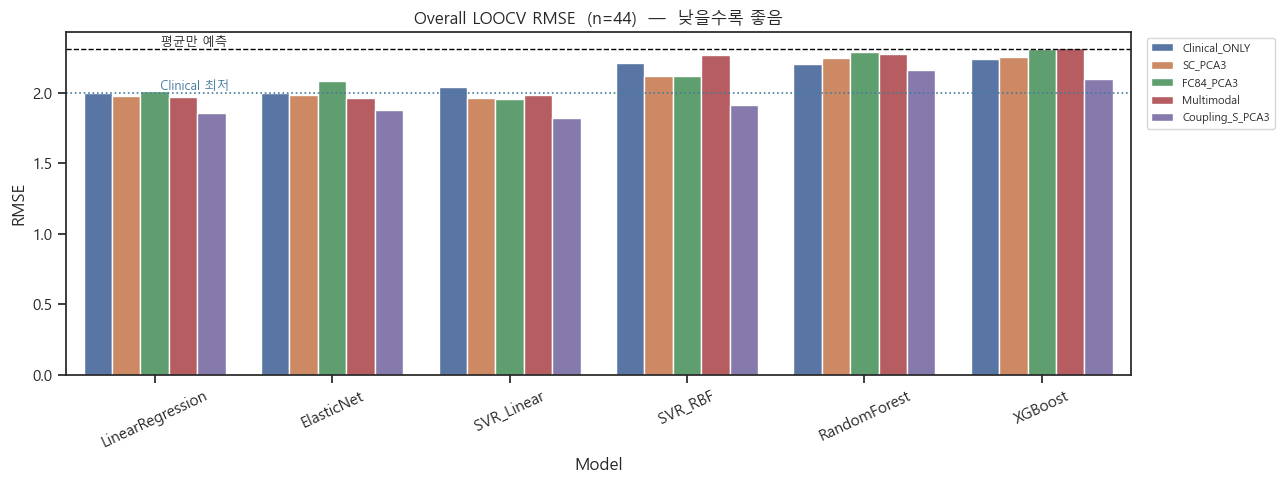

In [7]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[SC_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[SC_PCA3 / ElasticNet] 고유 4개, 최빈 91%
[SC_PCA3 / SVR_Linear] 고유 12개, 최빈 32%   <-- 불안정
[SC_PCA3 / SVR_RBF] 고유 6개, 최빈 82%
[SC_PCA3 / RandomForest] 고유 12개, 최빈 20%   <-- 불안정
[SC_PCA3 / XGBoost] 고유 6개, 최빈 70%
[FC84_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[FC84_PCA3 / ElasticNet] 고유 6개, 최빈 36%   <-- 불안정
[FC84_PCA3 / SVR_Linear] 고유 12개, 최빈 23%   <-- 불안정
[FC84_PCA3 / SVR_RBF] 고유 15개, 최빈 30%   <-- 불안정
[FC84_PCA3 / RandomForest] 고유 7개, 최빈 84%
[FC84_PCA3 / XGBoost] 고유 9개, 최빈 36%   <-- 불안정
[Multimodal / LinearRegression] 고유 1개, 최빈 100%
[Multimodal / ElasticNet] 고유 6개, 최빈 75%
[Multimodal / SVR_Linear] 고유 7개, 최빈 66%
[Multimodal / SVR_RBF] 고유 14개, 최빈 41%   <-- 불안정
[Multimodal / RandomForest

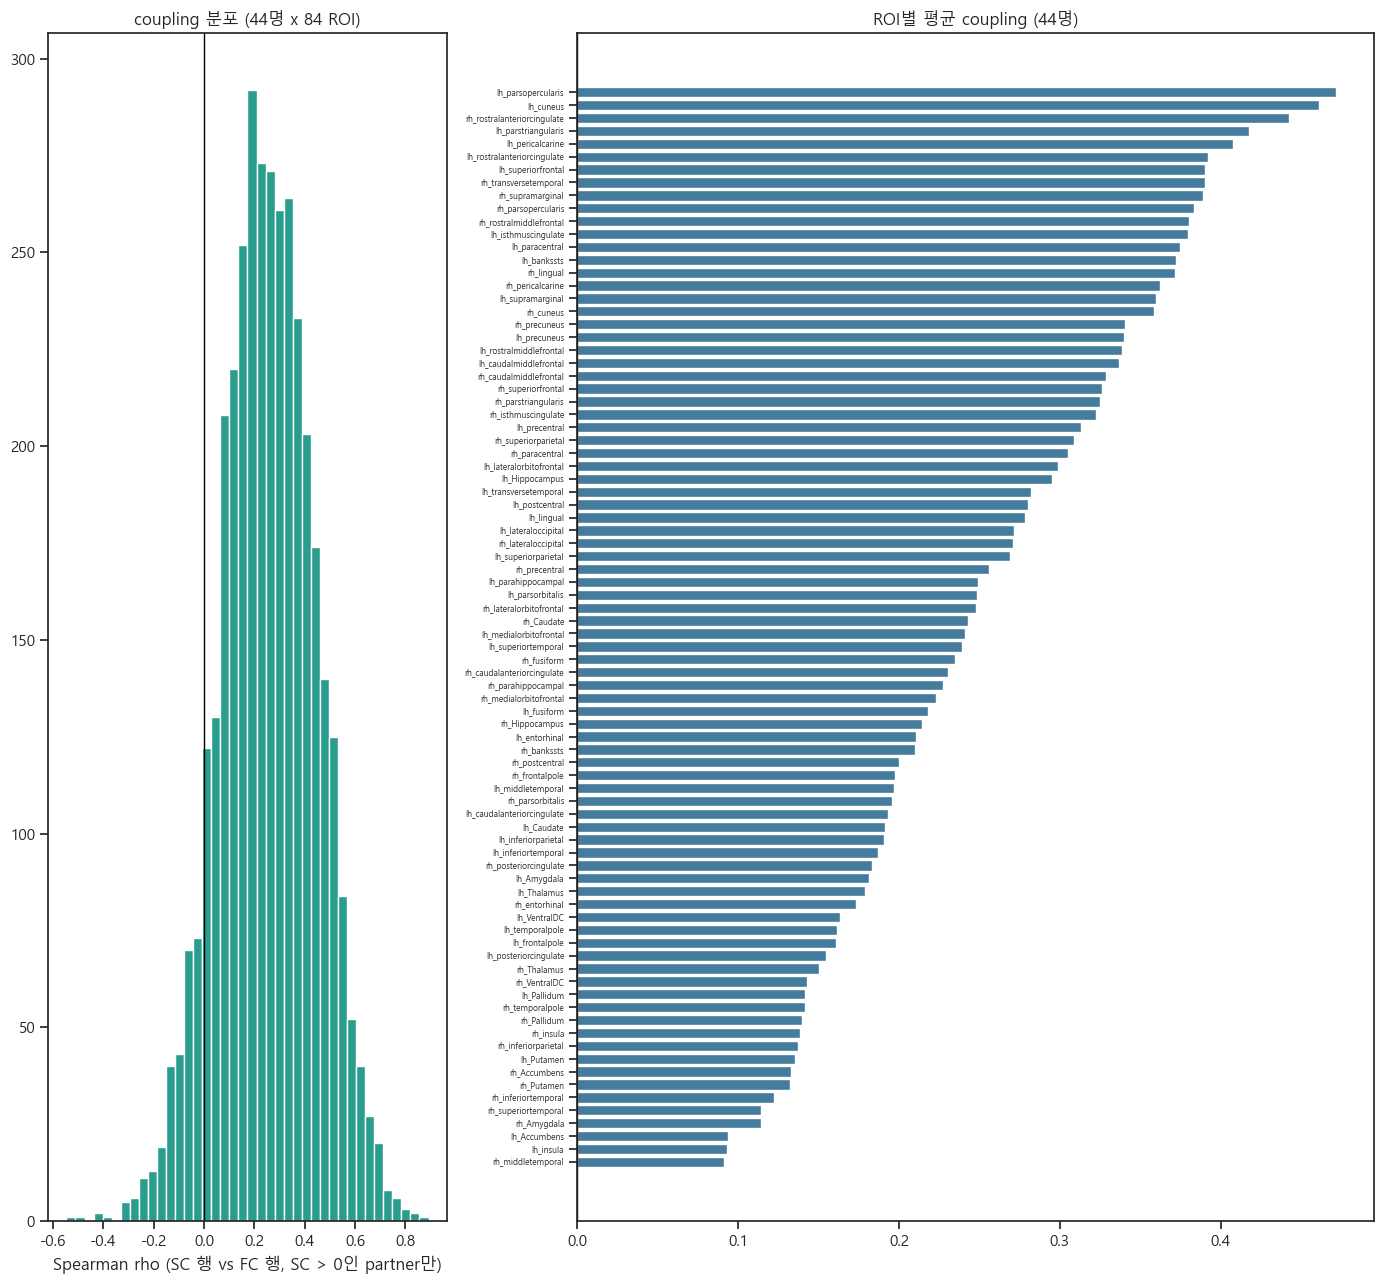

상위 5:
lh_parsopercularis             0.472
lh_cuneus                      0.461
rh_rostralanteriorcingulate    0.442
lh_parstriangularis            0.418
lh_pericalcarine               0.408

하위 5:
rh_middletemporal      0.091
lh_insula              0.093
lh_Accumbens           0.094
rh_Amygdala            0.114
rh_superiortemporal    0.114

0이 아닌 partner 수가 가장 적은 영역 (사람들 중 최소값):
rh_Accumbens              4
rh_transversetemporal     5
lh_bankssts               6
lh_frontalpole            9
rh_paracentral            9
lh_transversetemporal    11
rh_frontalpole           11
lh_paracentral           11


In [9]:
# ==========================================================
# 8. Coupling 기술통계 (sanity check — 예측과 무관, vas를 쓰지 않음)
#    선행연구: 감각·시각 피질은 coupling이 높고 연합 피질(DMN 등)은 낮다.
# ==========================================================
cp = pd.DataFrame(X_coup, columns=ROIS_CP)
roi_mean = cp.mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 13), gridspec_kw={'width_ratios': [1, 2]})
axes[0].hist(X_coup.ravel(), bins=40, color='#2A9D8F', edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title(f'coupling 분포 ({X_coup.shape[0]}명 x {X_coup.shape[1]} ROI)')
axes[0].set_xlabel('Spearman rho (SC 행 vs FC 행, SC > 0인 partner만)')

colors = ['#E63946' if v < 0 else '#457B9D' for v in roi_mean.values]
axes[1].barh(roi_mean.index, roi_mean.values, color=colors)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title(f'ROI별 평균 coupling ({X_coup.shape[0]}명)')
axes[1].tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

print('상위 5:'); print(roi_mean.tail(5)[::-1].round(3).to_string())
print('\n하위 5:'); print(roi_mean.head(5).round(3).to_string())

# partner가 적은 영역은 coupling이 불안정하다. 빼지는 않고 어디인지 적어 둔다.
few = pd.Series(n_partner.min(0), index=ROIS).sort_values().head(8)
print('\n0이 아닌 partner 수가 가장 적은 영역 (사람들 중 최소값):'); print(few.to_string())


## 결과 읽는 법

1. **따로 줄여서 붙이면 이득인가**: `Multimodal`이 `SC_PCA3`와 `FC84_PCA3` **둘 다**보다 낮아야 한다
   (`d_Multi_vs_SC`, `d_Multi_vs_FC84` 둘 다 +). 한쪽만 이기면 그 모달리티 하나가 끌고 간 것이다.
2. **coupling이 정보를 더하는가**: `d_Coup_vs_Clin`이 +.
3. **Active와 Sham**: 5번 셀과 10번 셀에서 군별 RMSE, r, R2를 나란히 본다. 모델은 44명 전체로 학습한 것이다.
4. **기준선**: `Clinical_ONLY`, 평균 예측 RMSE와 비교한다. 같은 44명이라 FC 단독·SC 단독(44명) 노트북과 기준선이 같다.
5. **연결 기준**: pass가 주 분석이다. end에서 방향이 다르면 결론이 연결 기준에 달려 있다는 뜻이고, 그렇게 적는다.
6. **하지 말 것**: coupling이 튀는 영역을 골라 피처로 쓰는 것. 같은 44명으로 고르면 leakage다.
   all / global / ROI / PCA 3 / PCA 5 중 잘 나온 것만 골라 보고하는 것도 같은 문제다. 전부 보고한다.


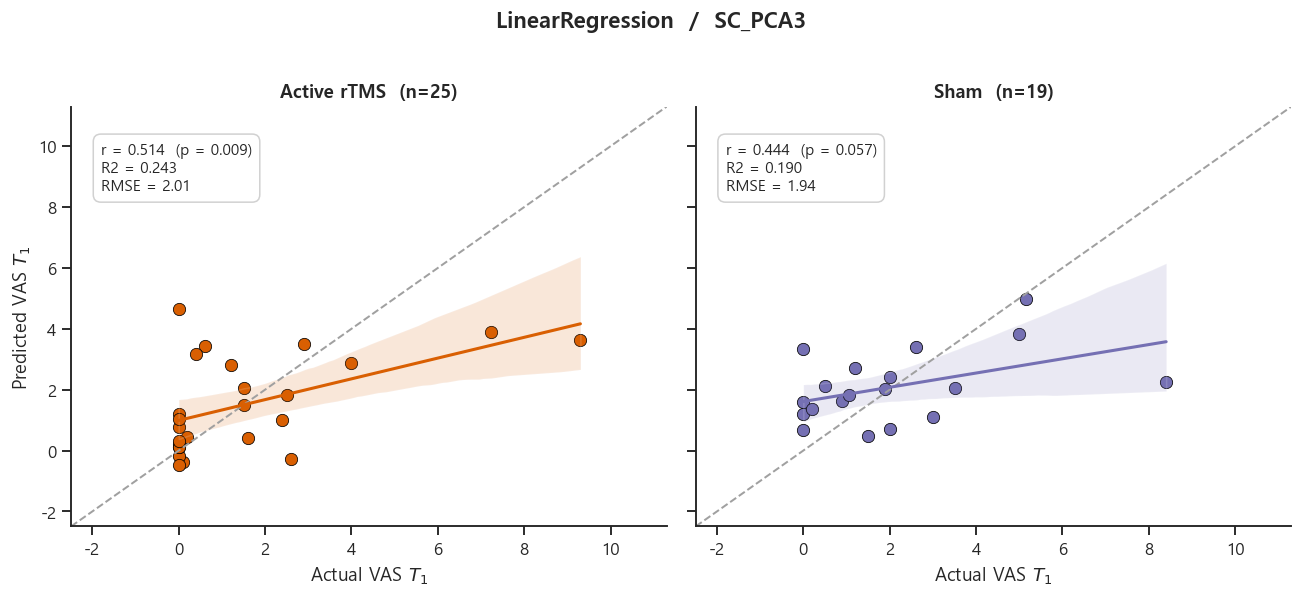

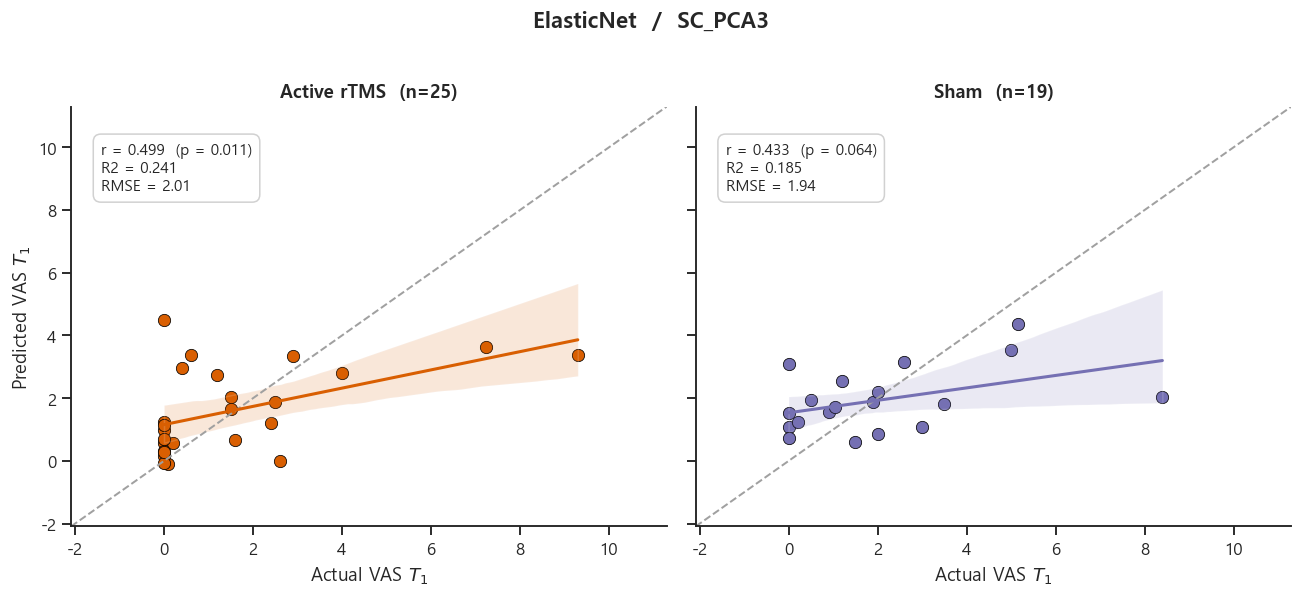

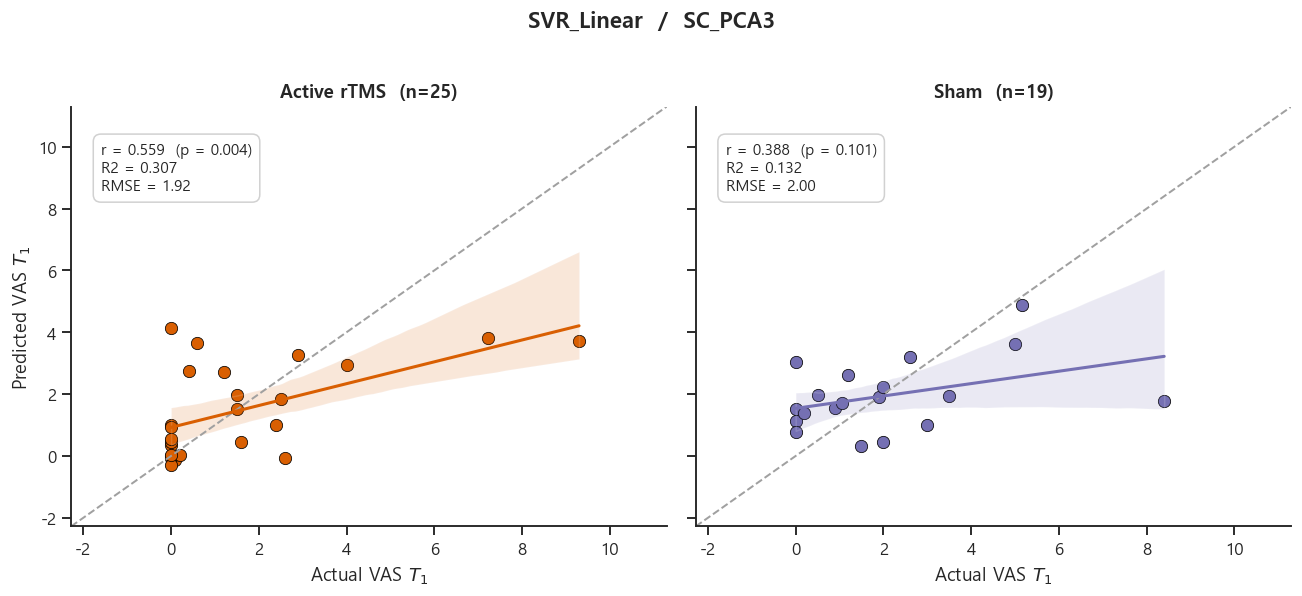

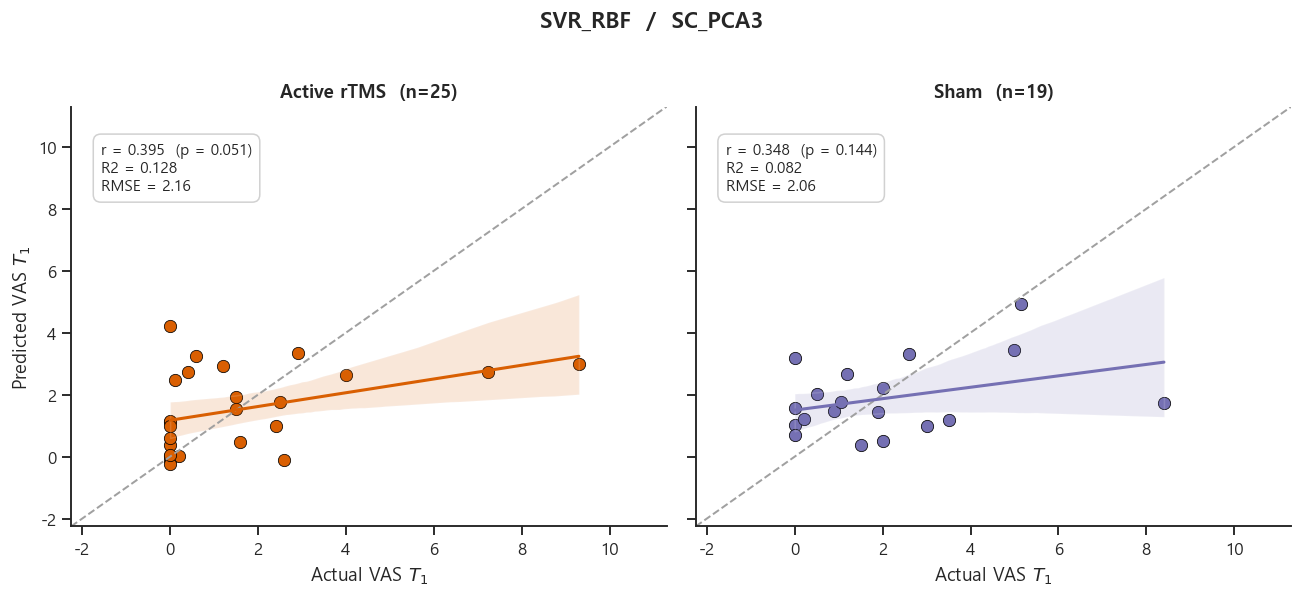

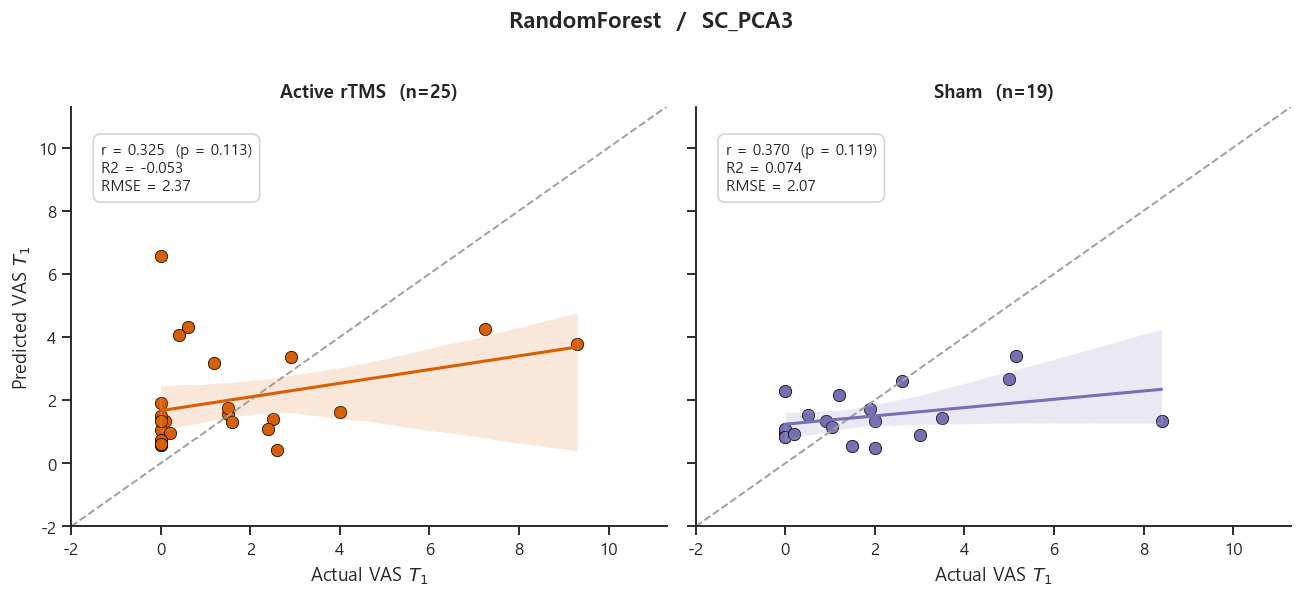

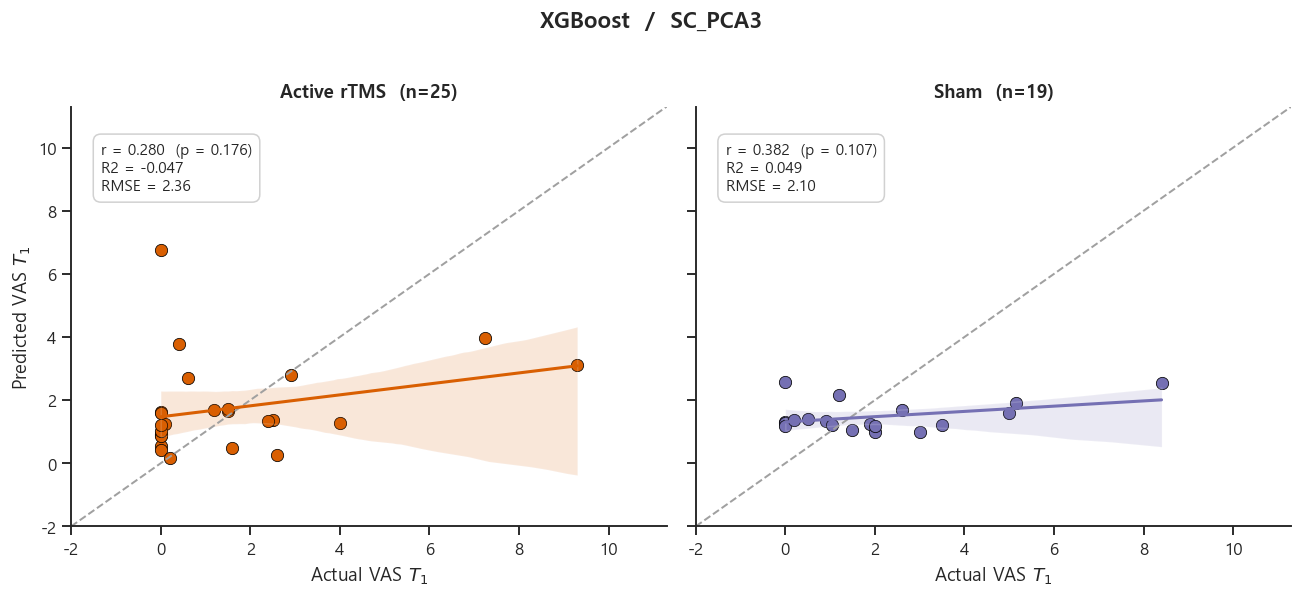

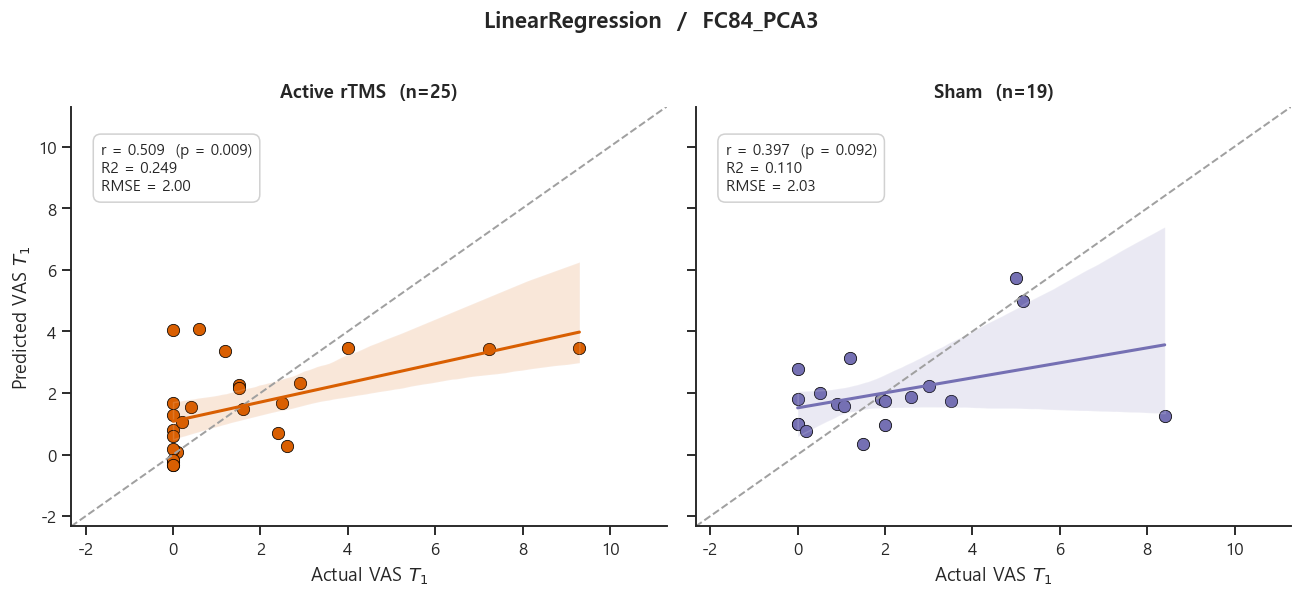

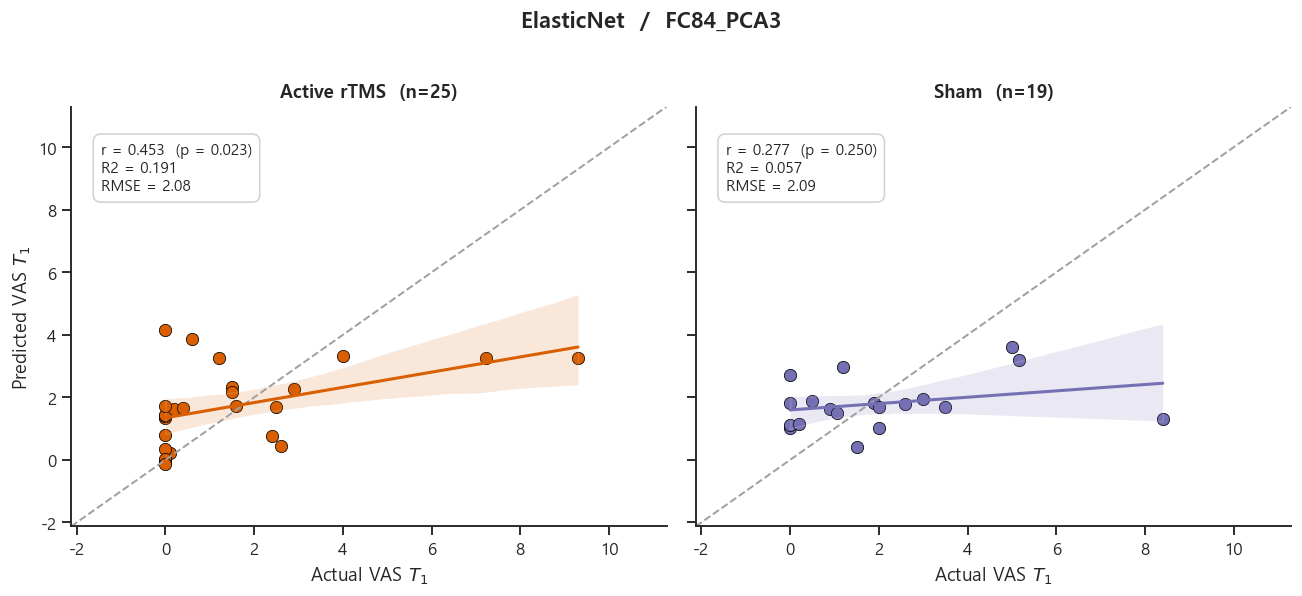

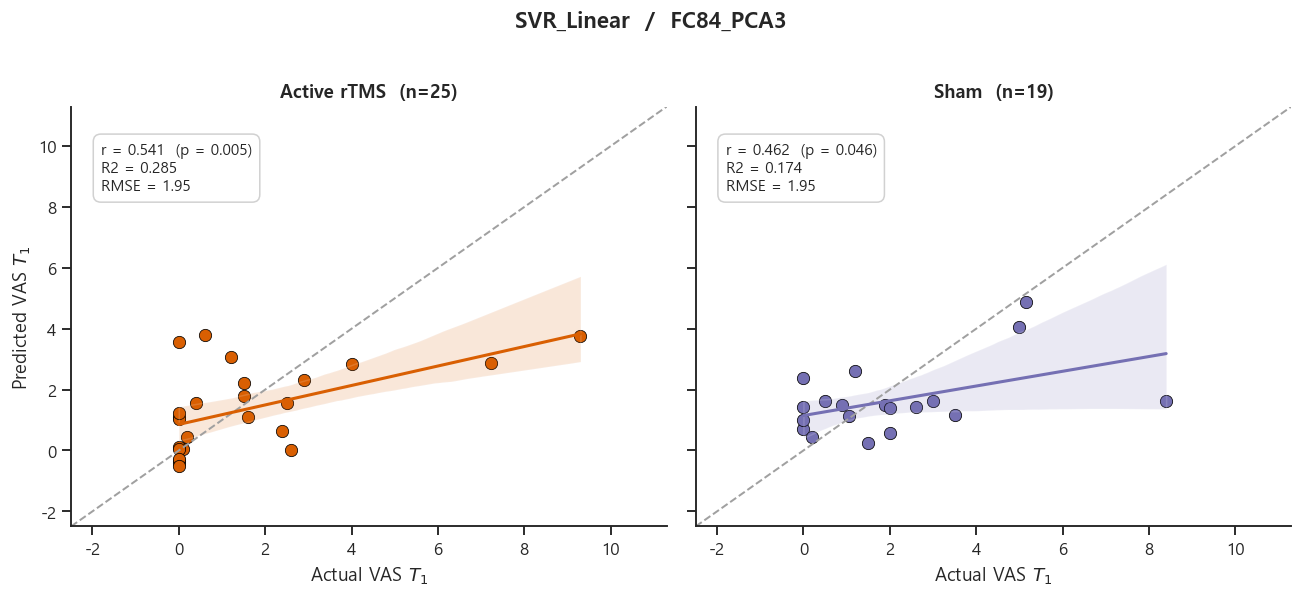

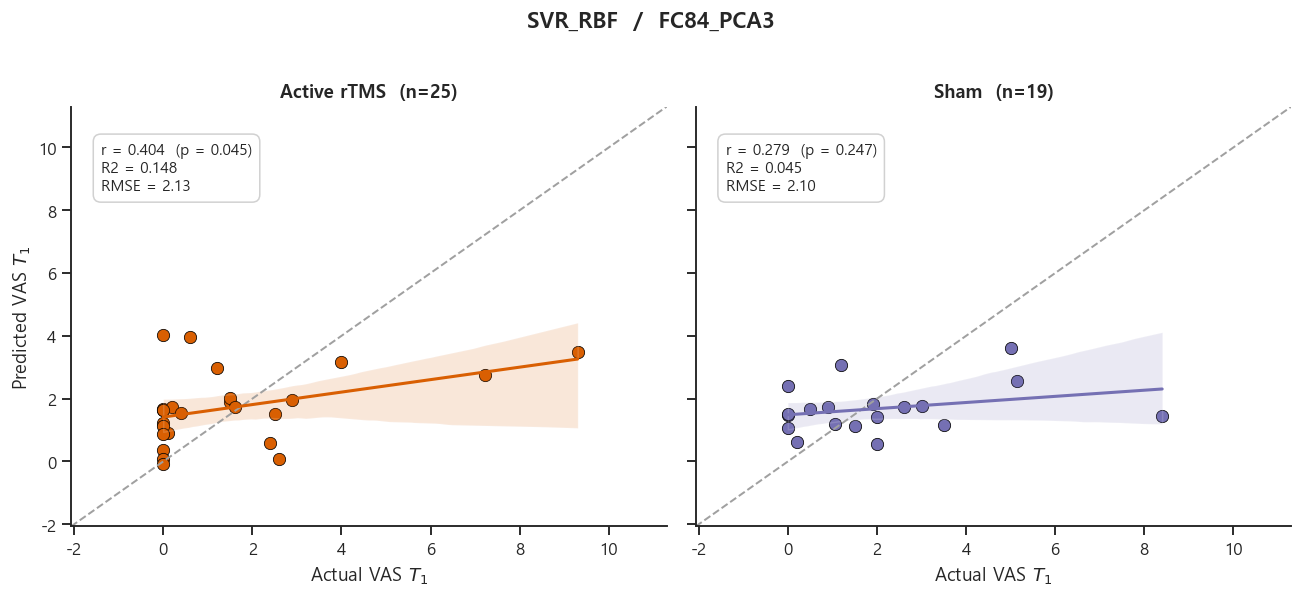

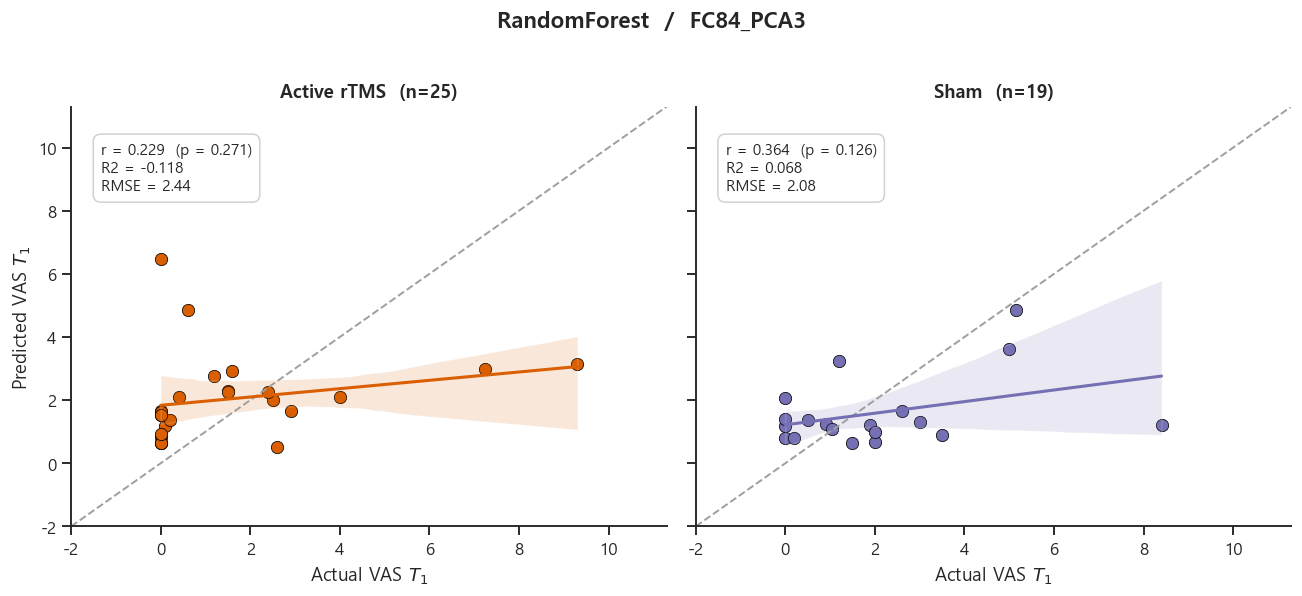

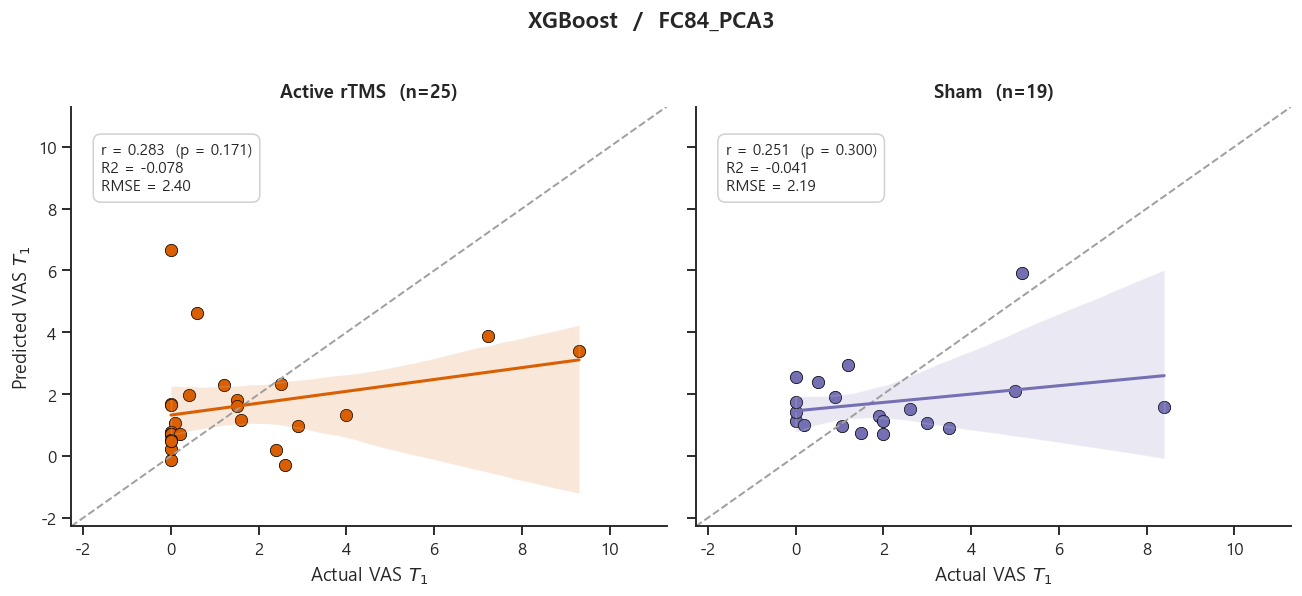

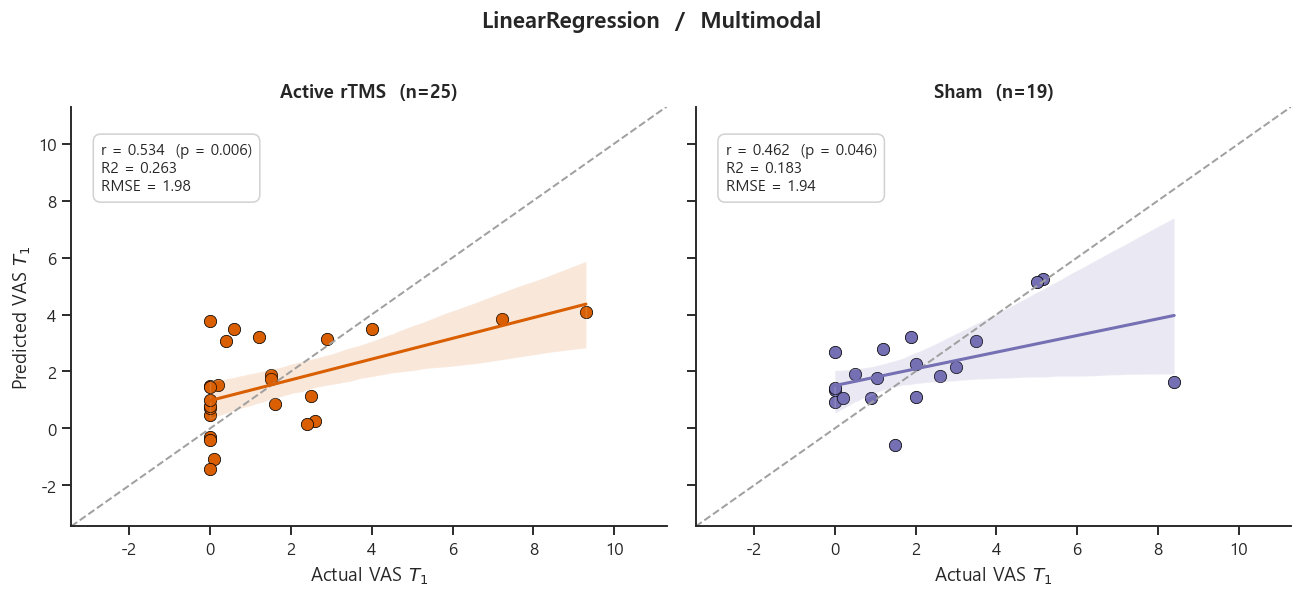

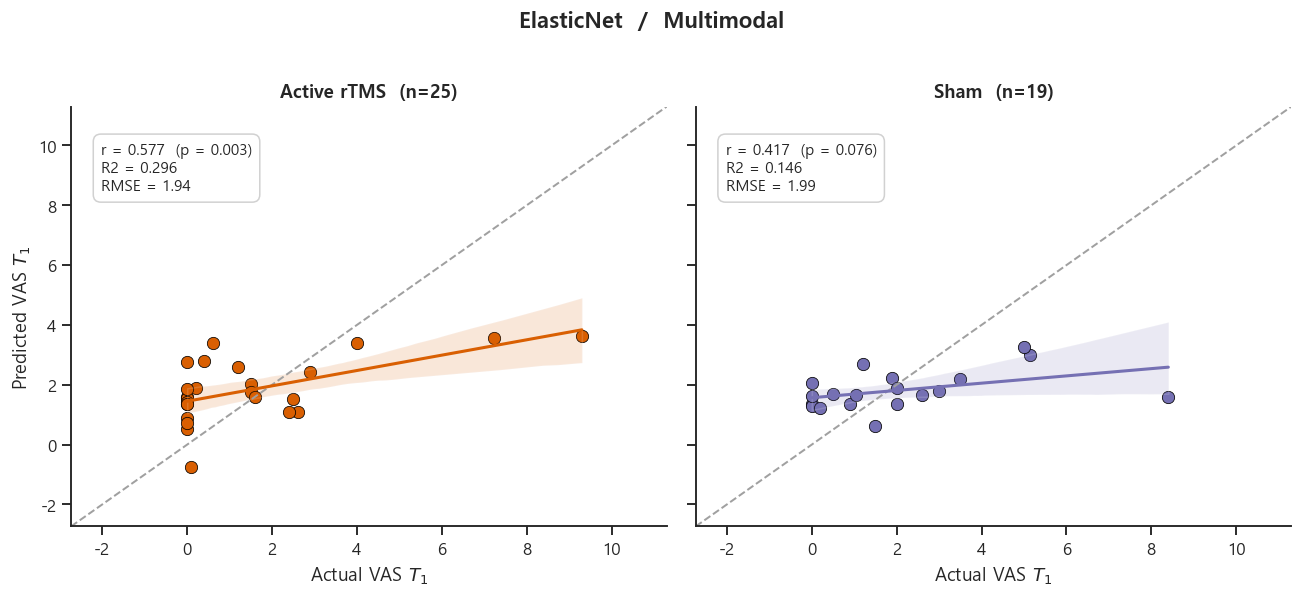

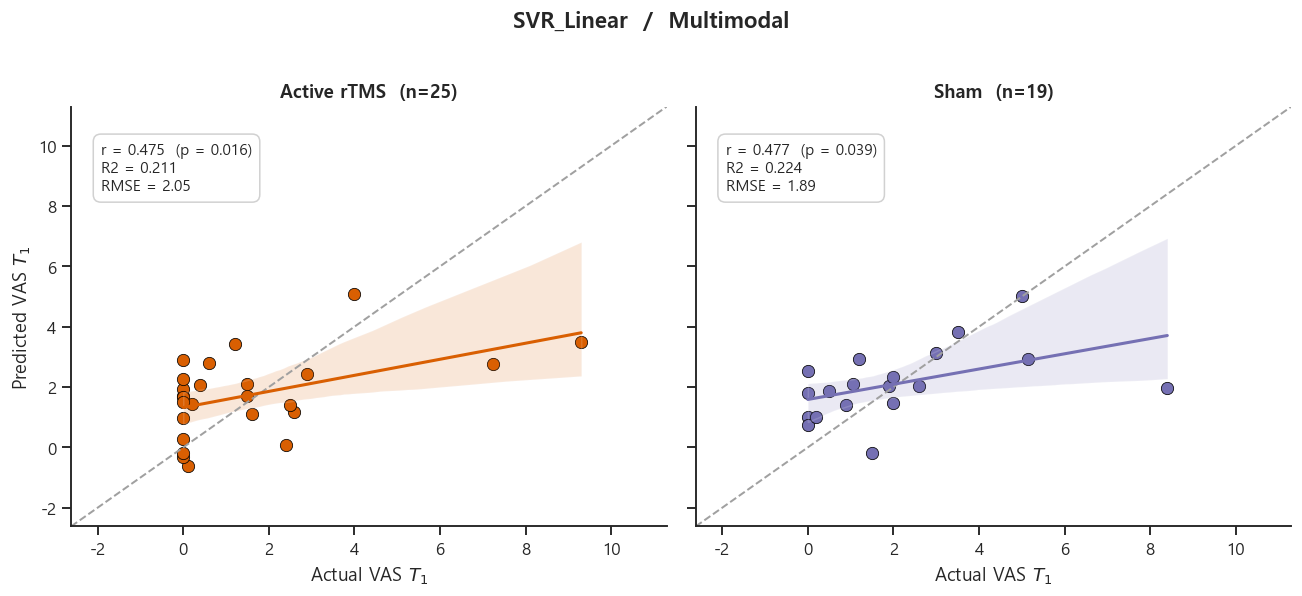

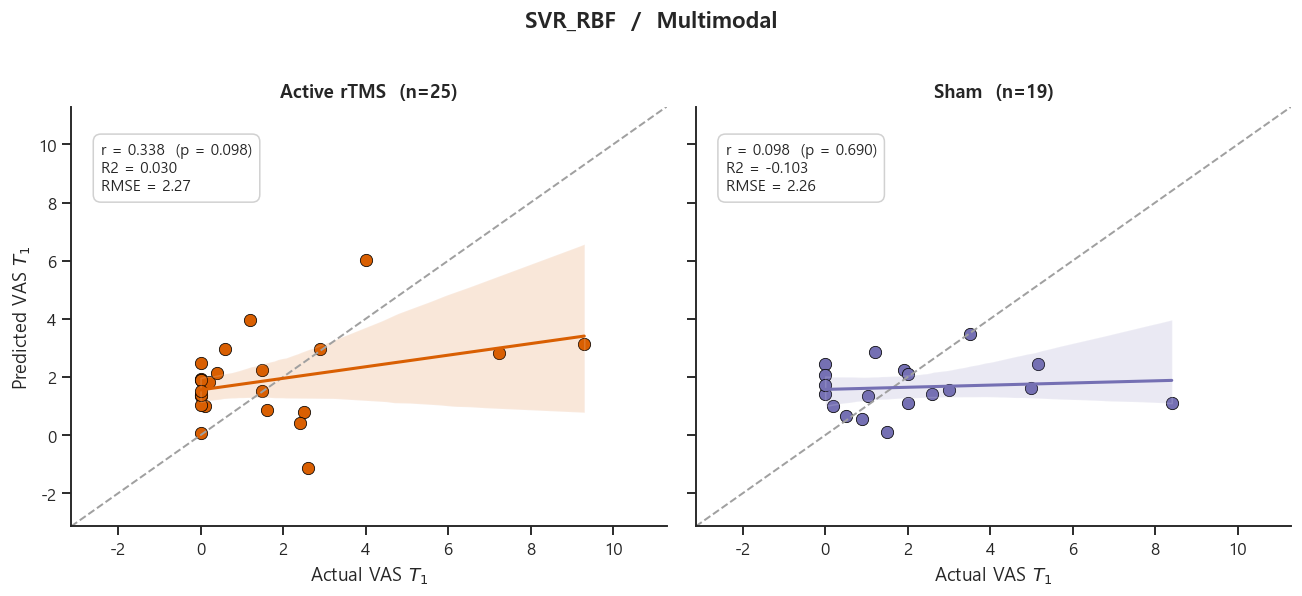

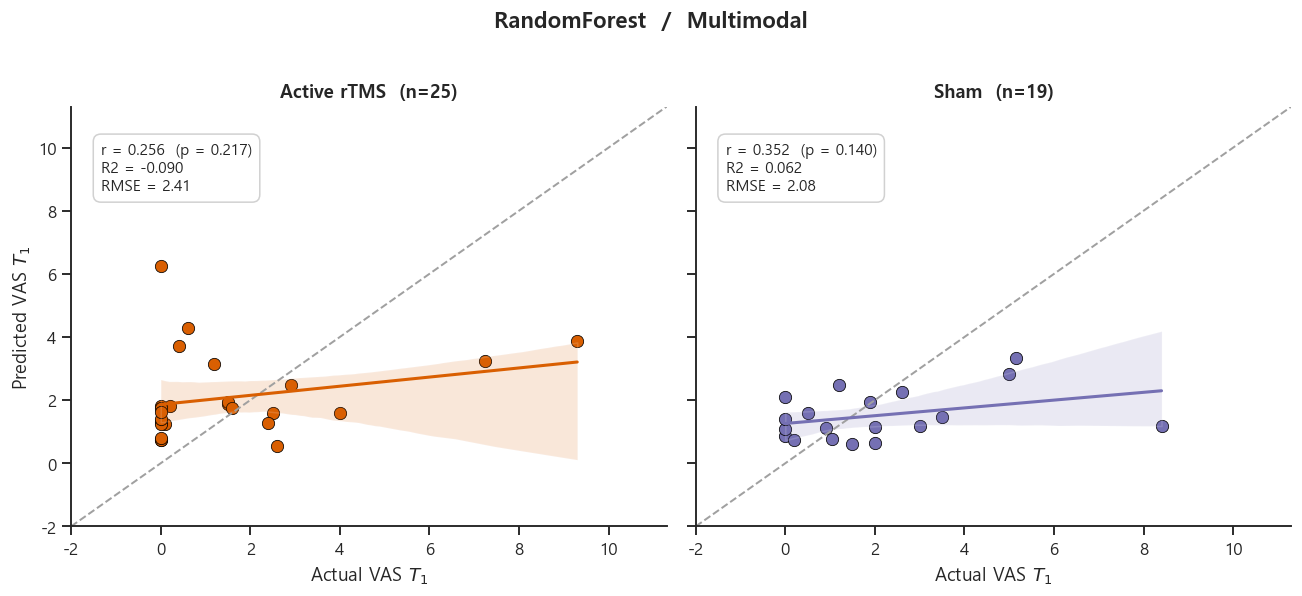

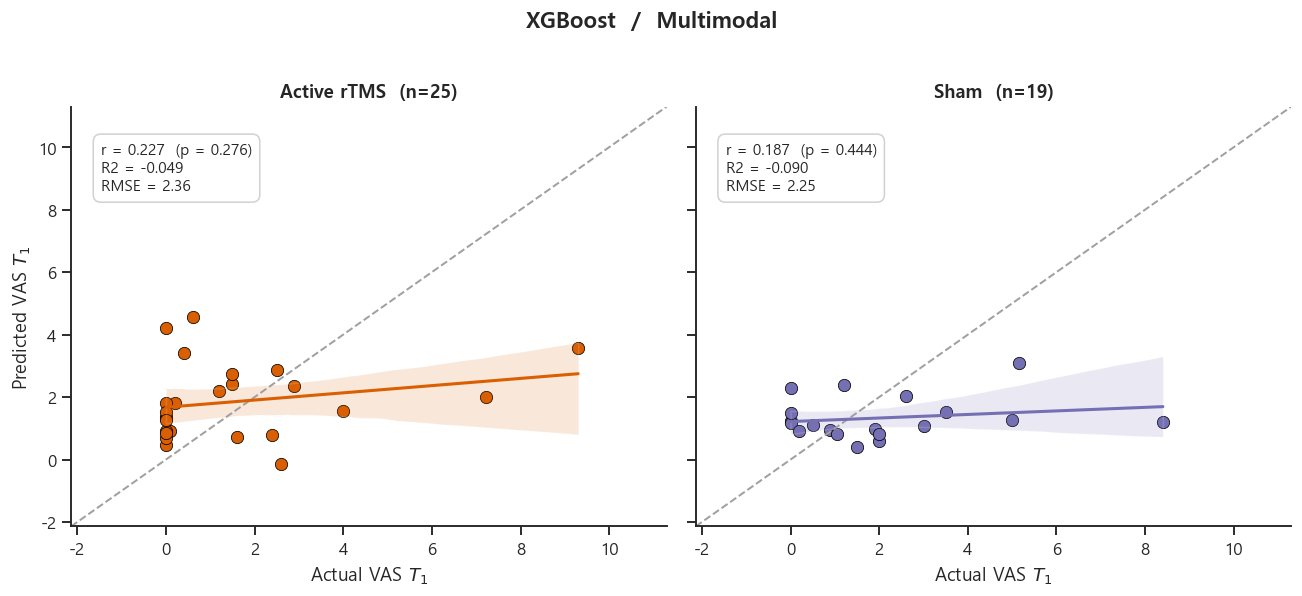

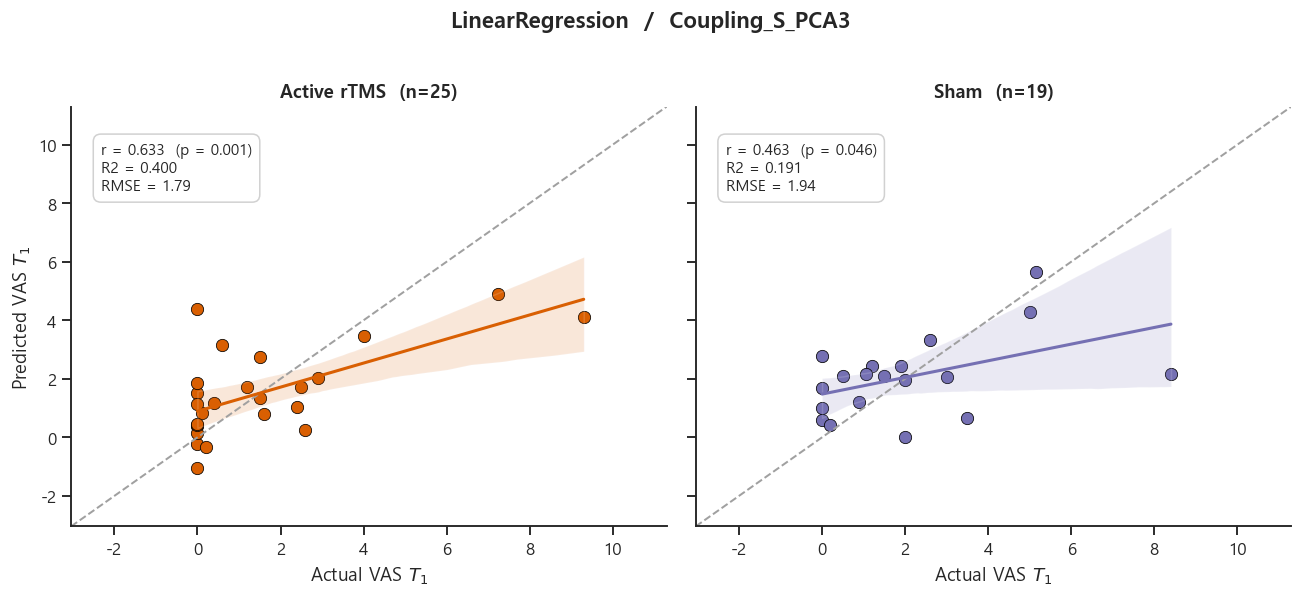

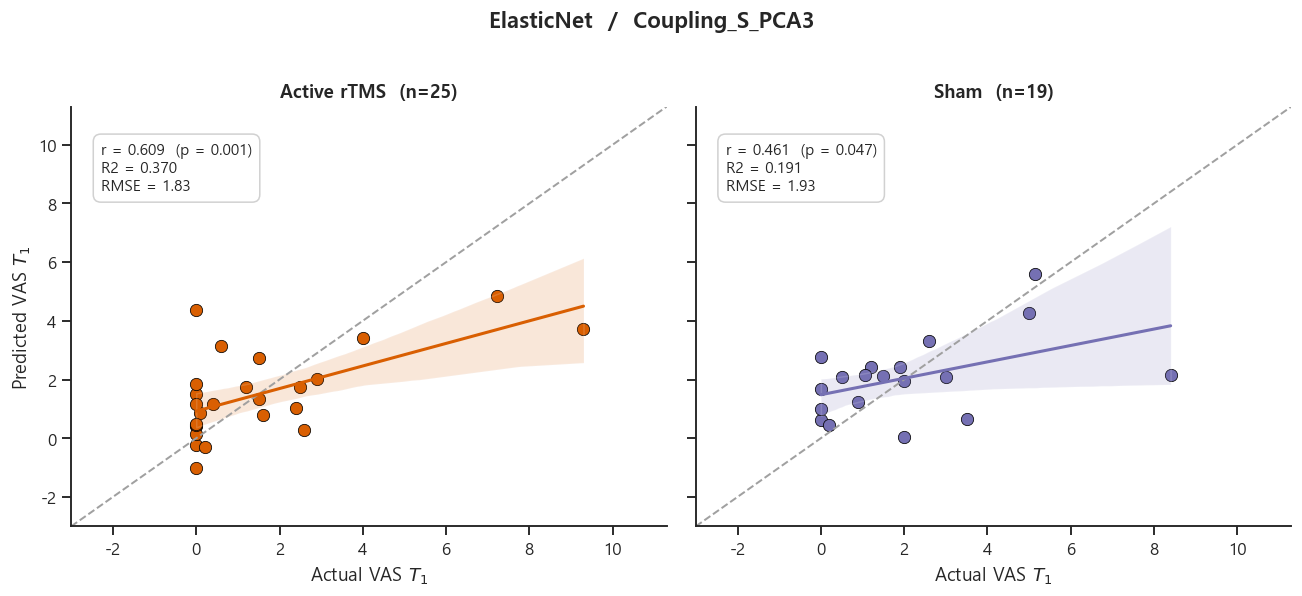

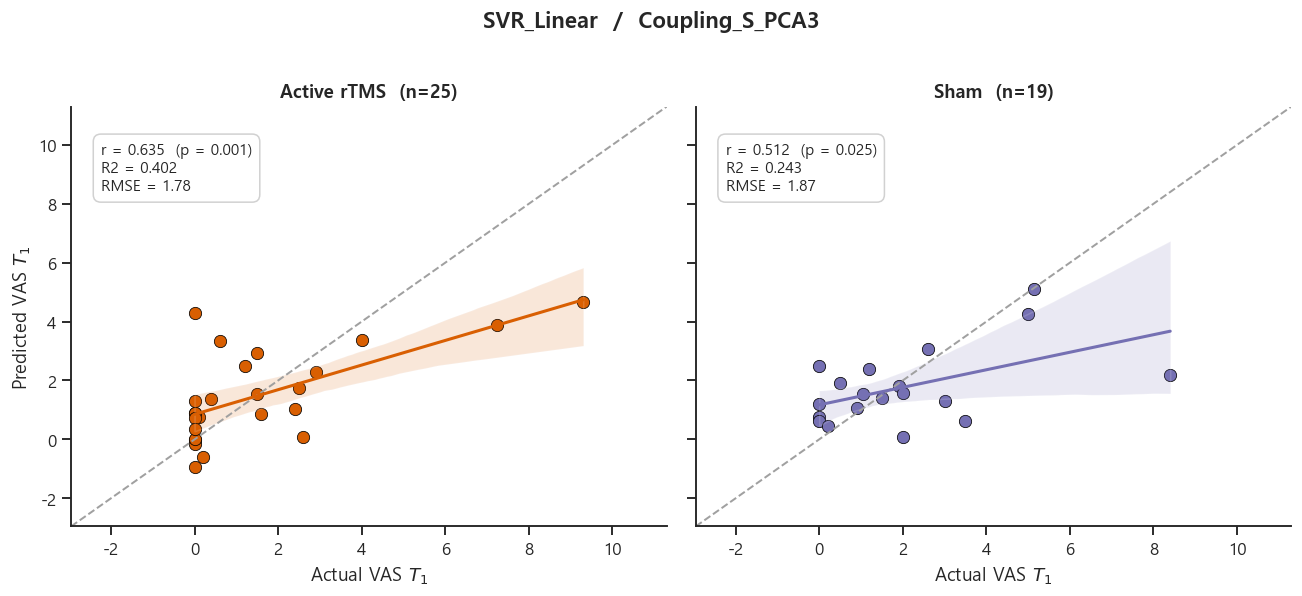

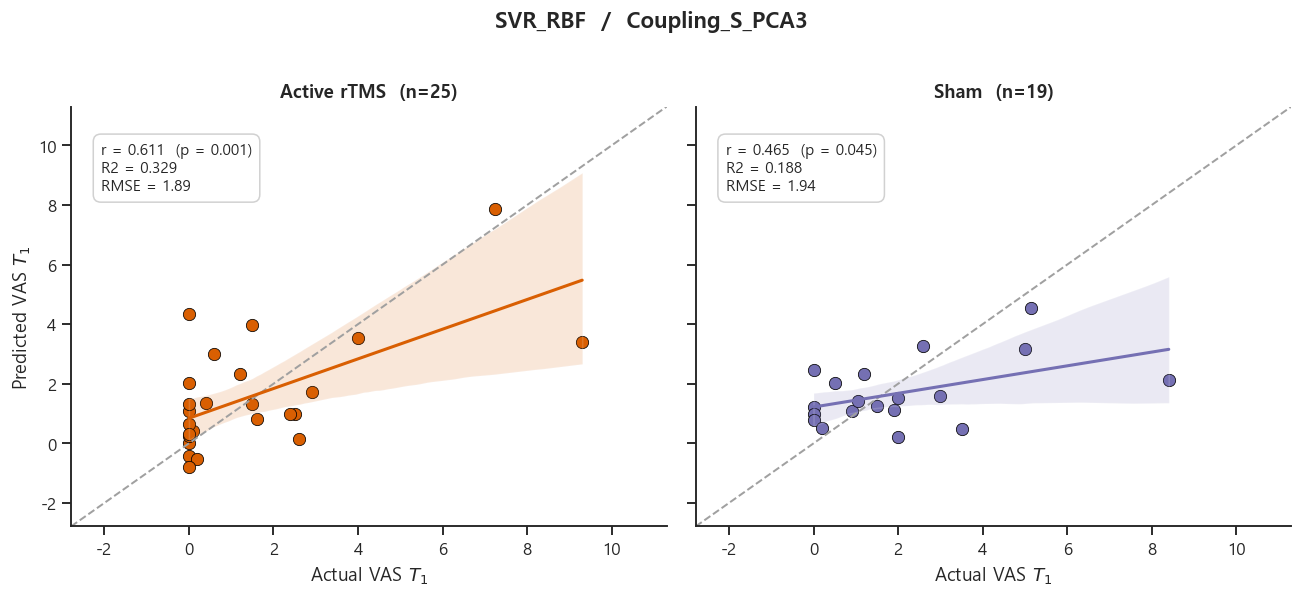

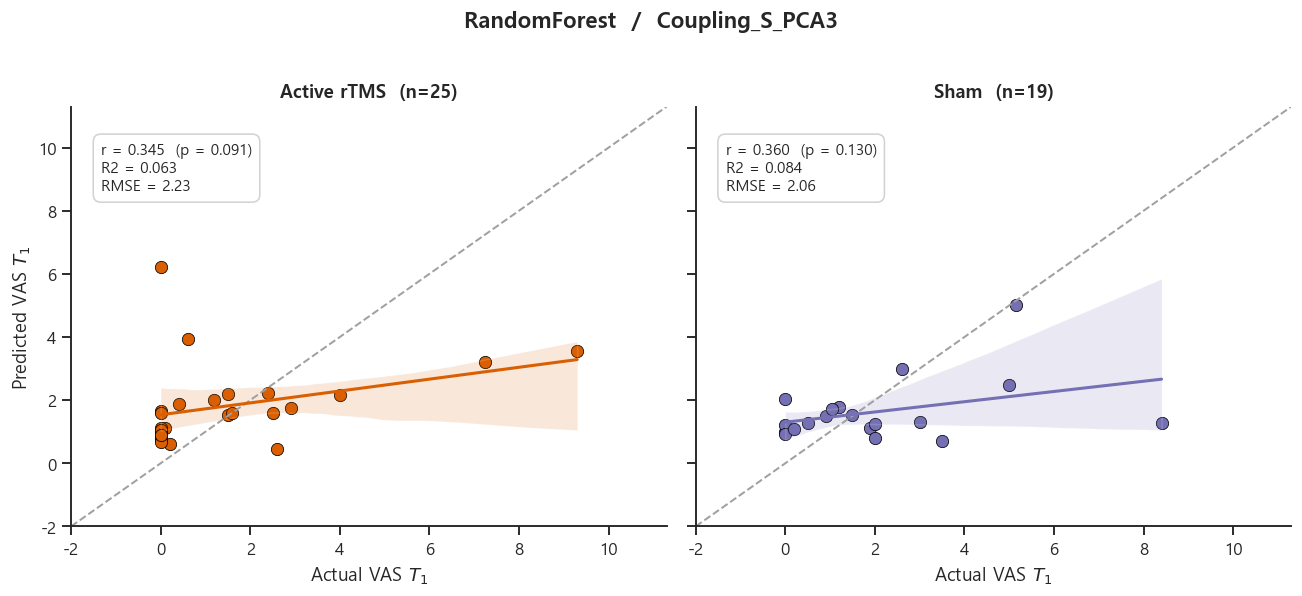

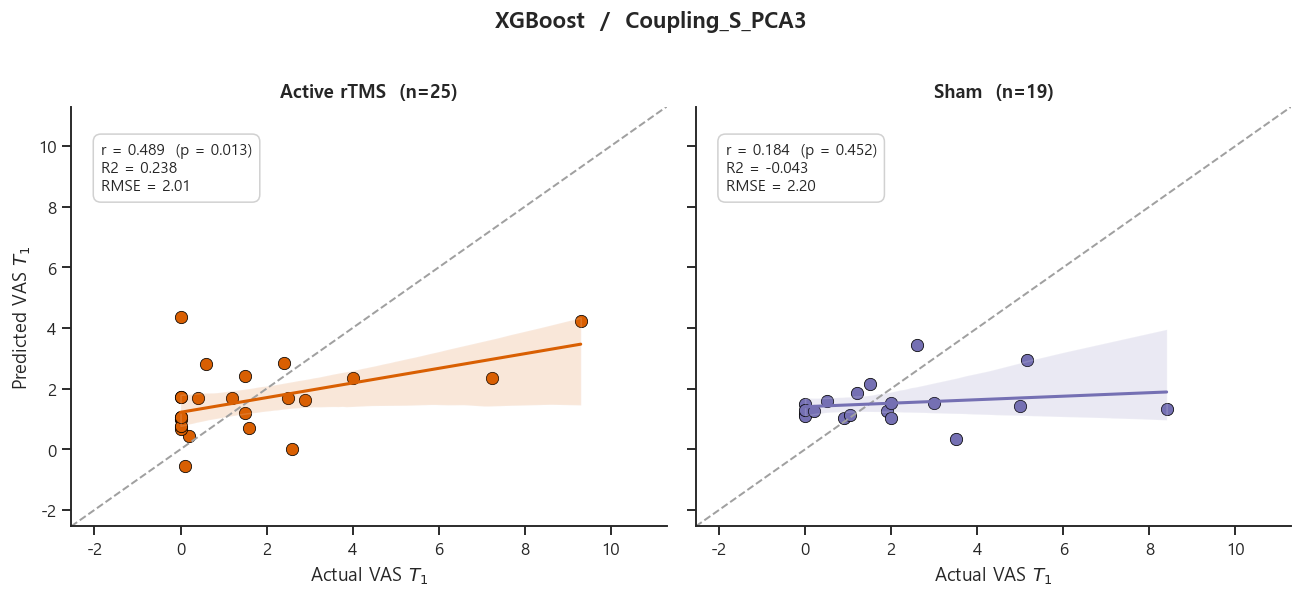

In [10]:
# ==========================================================
# 9. 산점도 — Active rTMS vs Sham 분리 (기존 멀티모달 노트북 8번 셀과 동일한 형식)
#    LOOCV 예측은 44명 전체로 학습한 것이고, 그림에서만 그룹을 나눠 본다.
# ==========================================================
PLOT_DATA_TYPES = ['SC_PCA3', 'FC84_PCA3', 'Multimodal', 'Coupling_S_PCA3']   # 줄이려면 여기서 빼기
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for (dt, name), preds in predictions.items():
    if dt not in PLOT_DATA_TYPES:
        continue
    yp = np.array(preds)
    pdf = pd.DataFrame({'Actual': y_true, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [11]:
# ==========================================================
# 10. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#     (그림에 찍힌 값과 같은 숫자다. 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
rows_sc = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

# --- 넓은 표: 행 = 피처셋 x 모델, 열 = Active/Sham x 지표 ---
wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

# --- 좁은 표: RMSE와 r만, 두 군을 나란히 ---
print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

# --- 군별로 가장 좋았던 조합 ---
print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                            Active                        Sham         \
                                   RMSE     R2      r      p   RMSE     R2   
Data Type       Model                                                        
Clinical_ONLY   LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
                ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
                SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
                SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
                RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
                XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
SC_PCA3         LinearRegression  2.009  0.243  0.514  0.009  1.937  0.190   
                ElasticNet        2.010  0.241  0.499  0.011  1.943  0.185   
                SVR_Linear        1.922  0.307  0.559  0.004  2.005  0.132   
                SVR_RBF           2.155  0.128  0.395  0.051  2.061  0.082   
                RandomForest      2.368 -0.053  0.325  0.113  2.071  0.074   
                XGBoost           2.362 -0.047  0.280  0.176  2.098  0.049   
FC84_PCA3       LinearRegression  2.000  0.249  0.509  0.009  2.029  0.110   
                ElasticNet        2.075  0.191  0.453  0.023  2.090  0.057   
                SVR_Linear        1.952  0.285  0.541  0.005  1.955  0.174   
                SVR_RBF           2.130  0.148  0.404  0.045  2.103  0.045   
                RandomForest      2.440 -0.118  0.229  0.271  2.077  0.068   
                XGBoost           2.396 -0.078  0.283  0.171  2.195 -0.041   
Multimodal      LinearRegression  1.981  0.263  0.534  0.006  1.944  0.183   
                ElasticNet        1.936  0.296  0.577  0.003  1.988  0.146   
                SVR_Linear        2.050  0.211  0.475  0.016  1.895  0.224   
                SVR_RBF           2.273  0.030  0.338  0.098  2.259 -0.103   
                RandomForest      2.409 -0.090  0.256  0.217  2.084  0.062   
                XGBoost           2.363 -0.049  0.227  0.276  2.246 -0.090   
Coupling_S_PCA3 LinearRegression  1.787  0.400  0.633  0.001  1.935  0.191   
                ElasticNet        1.831  0.370  0.609  0.001  1.935  0.191   
                SVR_Linear        1.785  0.402  0.635  0.001  1.872  0.243   
                SVR_RBF           1.890  0.329  0.611  0.001  1.939  0.188   
                RandomForest      2.235  0.063  0.345  0.091  2.059  0.084   
                XGBoost           2.014  0.238  0.489  0.013  2.197 -0.043   

Group                                           
                                      r      p  
Data Type       Model                           
Clinical_ONLY   LinearRegression  0.402  0.088  
                ElasticNet        0.402  0.088  
                SVR_Linear        0.400  0.090  
                SVR_RBF           0.329  0.170  
                RandomForest      0.302  0.209  
                XGBoost           0.307  0.202  
SC_PCA3         LinearRegression  0.444  0.057  
                ElasticNet        0.433  0.064  
                SVR_Linear        0.388  0.101  
                SVR_RBF           0.348  0.144  
                RandomForest      0.370  0.119  
                XGBoost           0.382  0.107  
FC84_PCA3       LinearRegression  0.397  0.092  
                ElasticNet        0.277  0.250  
                SVR_Linear        0.462  0.046  
                SVR_RBF           0.279  0.247  
                RandomForest      0.364  0.126  
                XGBoost           0.251  0.300  
Multimodal      LinearRegression  0.462  0.046  
                ElasticNet        0.417  0.076  
                SVR_Linear        0.477  0.039  
                SVR_RBF           0.098  0.690  
                RandomForest      0.352  0.140  
                XGBoost           0.187  0.444  
Coupling_S_PCA3 LinearRegression  0.463  0.046  
                ElasticNet        0.461  0.047  
    


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  r_Sham  \
Data Type       Model                                                        
Clinical_ONLY   LinearRegression        2.004      1.989     0.507   0.402   
                ElasticNet              2.003      1.988     0.507   0.402   
                SVR_Linear              2.055      2.022     0.475   0.400   
                SVR_RBF                 2.291      2.095     0.358   0.329   
                RandomForest            2.261      2.118     0.356   0.302   
                XGBoost                 2.341      2.089     0.319   0.307   
SC_PCA3         LinearRegression        2.009      1.937     0.514   0.444   
                ElasticNet              2.010      1.943     0.499   0.433   
                SVR_Linear              1.922      2.005     0.559   0.388   
                SVR_RBF                 2.155      2.061     0.395   0.348   
                RandomForest            2.368      2.071     0.325   0.370   
                XGBoost                 2.362      2.098     0.280   0.382   
FC84_PCA3       LinearRegression        2.000      2.029     0.509   0.397   
                ElasticNet              2.075      2.090     0.453   0.277   
                SVR_Linear              1.952      1.955     0.541   0.462   
                SVR_RBF                 2.130      2.103     0.404   0.279   
                RandomForest            2.440      2.077     0.229   0.364   
                XGBoost                 2.396      2.195     0.283   0.251   
Multimodal      LinearRegression        1.981      1.944     0.534   0.462   
                ElasticNet              1.936      1.988     0.577   0.417   
                SVR_Linear              2.050      1.895     0.475   0.477   
                SVR_RBF                 2.273      2.259     0.338   0.098   
                RandomForest            2.409      2.084     0.256   0.352   
                XGBoost                 2.363      2.246     0.227   0.187   
Coupling_S_PCA3 LinearRegression        1.787      1.935     0.633   0.463   
                ElasticNet              1.831      1.935     0.609   0.461   
                SVR_Linear              1.785      1.872     0.635   0.512   
                SVR_RBF                 1.890      1.939     0.611   0.465   
                RandomForest            2.235      2.059     0.345   0.360   
                XGBoost                 2.014      2.197     0.489   0.184   

                                  RMSE_diff  
Data Type       Model                        
Clinical_ONLY   LinearRegression      0.015  
                ElasticNet            0.015  
                SVR_Linear            0.033  
                SVR_RBF               0.196  
                RandomForest          0.143  
                XGBoost               0.252  
SC_PCA3         LinearRegression      0.072  
                ElasticNet            0.068  
                SVR_Linear           -0.083  
                SVR_RBF               0.094  
                RandomForest          0.298  
                XGBoost               0.264  
FC84_PCA3       LinearRegression     -0.029  
                ElasticNet           -0.015  
                SVR_Linear           -0.003  
                SVR_RBF               0.027  
                RandomForest          0.363  
                XGBoost               0.201  
Multimodal      LinearRegression      0.037  
                ElasticNet           -0.052  
                SVR_Linear            0.156  
                SVR_RBF               0.014  
                RandomForest          0.325  
                XGBoost               0.118  
Coupling_S_PCA3 LinearRegression     -0.148  
                ElasticNet           -0.104  
                SVR_Linear           -0.088  
                SVR_RBF              -0.049  
                RandomForest          0.176  
                XGBoost              -0.183


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,Coupling_S_PCA3,SVR_Linear,1.785,0.402,0.635,0.001
1,Coupling_S_PCA3,LinearRegression,1.787,0.400,0.633,0.001
2,Coupling_S_PCA3,ElasticNet,1.831,0.370,0.609,0.001
3,Coupling_S_PCA3,SVR_RBF,1.890,0.329,0.611,0.001
4,SC_PCA3,SVR_Linear,1.922,0.307,0.559,0.004



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,Coupling_S_PCA3,SVR_Linear,1.872,0.243,0.512,0.025
1,Multimodal,SVR_Linear,1.895,0.224,0.477,0.039
2,Coupling_S_PCA3,ElasticNet,1.935,0.191,0.461,0.047
3,Coupling_S_PCA3,LinearRegression,1.935,0.191,0.463,0.046
4,SC_PCA3,LinearRegression,1.937,0.190,0.444,0.057
